<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from mlxtend.plotting import plot_decision_regions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [5]:

# We Load the dataset
stock_px = pd.read_csv("stock_px.csv", index_col=0, parse_dates=True)

# Convert prices → daily returns
returns = stock_px.pct_change().dropna()

print(returns.head())


                       AA      AAPL        GE       IBM       JNJ  MSFT  \
02/02/1990 0:00  0.012048  0.017812  0.000000  0.005956  0.023419   0.0   
05/02/1990 0:00  0.005952  0.022500  0.000000  0.025459 -0.006865   0.0   
06/02/1990 0:00 -0.011834 -0.007335  0.003484  0.013857 -0.004608   0.0   
07/02/1990 0:00  0.005988 -0.043103  0.010417  0.021071  0.013889   0.0   
08/02/1990 0:00  0.000000 -0.007722  0.003436 -0.003904  0.018265   0.0   

                      PEP       SPX       XOM  
02/02/1990 0:00  0.008278  0.006478  0.019608  
05/02/1990 0:00 -0.006568  0.002810  0.001603  
06/02/1990 0:00  0.016529 -0.006599 -0.003200  
07/02/1990 0:00  0.003252  0.012407  0.016051  
08/02/1990 0:00  0.008104 -0.002367  0.003160  


In [6]:
# we descrie basic statistic details about the data
returns.describe()


,AA,AAPL,GE,IBM,JNJ,MSFT,PEP,SPX,XOM
count,5471.000000,5471.000000,5471.000000,5471.000000,5471.000000,5471.000000,5471.000000,5471.000000,5471.000000
mean,0.000434,0.001220,0.000497,0.000619,0.000602,0.000963,0.000556,0.000310,0.000585
std,0.024615,0.031021,0.018783,0.018699,0.014510,0.021718,0.016128,0.011803,0.015451
min,-0.161332,-0.518505,-0.128068,-0.155364,-0.158484,-0.156028,-0.119339,-0.090350,-0.139528
25%,-0.012062,-0.015294,-0.008313,-0.008951,-0.007202,-0.010253,-0.007796,-0.004885,-0.007813
50%,0.000000,0.000000,0.000000,0.000134,0.000000,0.000000,0.000000,0.000555,0.000000
75%,0.012560,0.016791,0.009535,0.009558,0.007734,0.011926,0.008576,0.005801,0.008998
max,0.233588,0.331984,0.197388,0.131582,0.122396,0.195770,0.161080,0.115800,0.171956


In [7]:
# we check for  missing  values
print(returns.isnull().sum())


AA      0
AAPL    0
GE      0
IBM     0
JNJ     0
MSFT    0
PEP     0
SPX     0
XOM     0
dtype: int64


In [8]:
## observing the shape of the data
returns.shape


(5471, 9)

In [9]:
#Dataset  info
returns.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5471 entries, 02/02/1990 0:00 to 14/10/2011 0:00
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AA      5471 non-null   float64
 1   AAPL    5471 non-null   float64
 2   GE      5471 non-null   float64
 3   IBM     5471 non-null   float64
 4   JNJ     5471 non-null   float64
 5   MSFT    5471 non-null   float64
 6   PEP     5471 non-null   float64
 7   SPX     5471 non-null   float64
 8   XOM     5471 non-null   float64
dtypes: float64(9)
memory usage: 427.4+ KB


In [10]:
returns.dtypes


,0
AA,float64
AAPL,float64
GE,float64
IBM,float64
JNJ,float64
MSFT,float64
PEP,float64
SPX,float64
XOM,float64


In [11]:
# Choose Features (X) and Target (y)
X = returns[['MSFT', 'IBM', 'SPX', 'XOM']]  # predictors
y = returns['AAPL']  # target



In [12]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # keep time order
)


In [13]:
#Train a Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [14]:
#Make Predictions
y_pred = model.predict(X_test)


In [15]:
# we evaluate the  model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)



mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

RMSE: 0.01840634559757364
R²: 0.4591854887814826


In [16]:
#Interpret the Model Coefficients
coeffs = pd.Series(model.coef_, index=X.columns)
print(coeffs)


MSFT    0.191310
IBM     0.205084
SPX     0.946234
XOM    -0.158253
dtype: float64


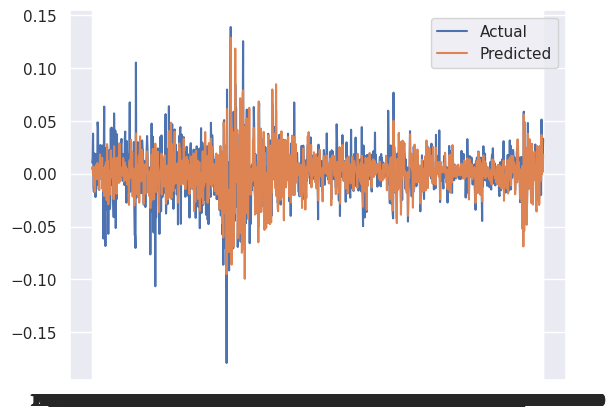

In [17]:
#Visual Evaluation (Optional but Powerful)
import matplotlib.pyplot as plt

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.show()
